In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report



In [2]:
file_path = r"H:\Master Files\cleaned_data.xlsx"

# Read the Excel file
df = pd.read_excel(file_path, engine="openpyxl")
df.head()

,CASE_NO_PATIENT'S,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,Global developmental delay/intellectual disability,Social/Behavioural Issues,Childhood Autism Rating Scale,Anxiety_disorder,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who_completed_the_test,ASD_traits
0,1,0,0,0,0,0,0,1,1,0,...,Yes,Yes,1,Yes,F,middle eastern,Yes,No,Family Member,No
1,2,1,1,0,0,0,1,1,0,0,...,Yes,Yes,2,Yes,M,White European,Yes,No,Family Member,Yes
2,3,1,0,0,0,0,0,1,1,0,...,Yes,Yes,4,Yes,M,Middle Eastern,Yes,No,Family Member,Yes
3,4,1,1,1,1,1,1,1,1,1,...,Yes,Yes,2,Yes,M,Hispanic,No,No,Family Member,Yes
4,5,1,1,0,1,1,1,1,1,1,...,Yes,Yes,1,Yes,F,White European,No,No,Family Member,Yes


In [3]:
df.columns

Index(['CASE_NO_PATIENT'S', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8',
       'A9', 'A10_Autism_Spectrum_Quotient', 'Social_Responsiveness_Scale',
       'Age_Years', 'Qchat_10_Score', 'Speech Delay/Language Disorder',
       'Learning disorder', 'Genetic_Disorders', 'Depression',
       'Global developmental delay/intellectual disability',
       'Social/Behavioural Issues', 'Childhood Autism Rating Scale',
       'Anxiety_disorder', 'Sex', 'Ethnicity', 'Jaundice',
       'Family_mem_with_ASD', 'Who_completed_the_test', 'ASD_traits'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1923 entries, 0 to 1922
Data columns (total 28 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   CASE_NO_PATIENT'S                                   1923 non-null   int64 
 1   A1                                                  1923 non-null   int64 
 2   A2                                                  1923 non-null   int64 
 3   A3                                                  1923 non-null   int64 
 4   A4                                                  1923 non-null   int64 
 5   A5                                                  1923 non-null   int64 
 6   A6                                                  1923 non-null   int64 
 7   A7                                                  1923 non-null   int64 
 8   A8                                                  1923 non-null   int64 
 9   A9      

In [5]:
df.describe()

,CASE_NO_PATIENT'S,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10_Autism_Spectrum_Quotient,Social_Responsiveness_Scale,Age_Years,Qchat_10_Score,Childhood Autism Rating Scale
count,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000,1923.000000
mean,990.641706,0.302132,0.241810,0.215289,0.274571,0.279771,0.306292,0.347374,0.246490,0.261050,0.453458,3.141966,9.611024,4.217369,1.712949
std,577.501297,0.459302,0.428291,0.411129,0.446414,0.449003,0.461073,0.476260,0.431079,0.439322,0.497959,3.703518,4.310228,2.895612,1.022013
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,483.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,2.000000,1.000000
50%,984.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,9.000000,4.000000,1.000000
75%,1493.500000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,6.000000,14.000000,6.000000,2.000000
max,1985.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10.000000,18.000000,10.000000,4.000000


In [6]:
df.isnull().sum()

CASE_NO_PATIENT'S                                     0
A1                                                    0
A2                                                    0
A3                                                    0
A4                                                    0
A5                                                    0
A6                                                    0
A7                                                    0
A8                                                    0
A9                                                    0
A10_Autism_Spectrum_Quotient                          0
Social_Responsiveness_Scale                           0
Age_Years                                             0
Qchat_10_Score                                        0
Speech Delay/Language Disorder                        0
Learning disorder                                     0
Genetic_Disorders                                     0
Depression                                      

In [7]:
df.shape

(1923, 28)

In [8]:
# Step 2: Data Cleaning
# Drop irrelevant columns (e.g., patient ID)
df_cleaned = df.drop(columns=["CASE_NO_PATIENT'S"], errors='ignore')

In [9]:
# Clean column names (lowercase, remove spaces)
df_cleaned.columns = [col.strip().replace(" ", "_").lower() for col in df_cleaned.columns]

In [10]:
df.dropna()

,CASE_NO_PATIENT'S,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,Global developmental delay/intellectual disability,Social/Behavioural Issues,Childhood Autism Rating Scale,Anxiety_disorder,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who_completed_the_test,ASD_traits
0,1,0,0,0,0,0,0,1,1,0,...,Yes,Yes,1,Yes,F,middle eastern,Yes,No,Family Member,No
1,2,1,1,0,0,0,1,1,0,0,...,Yes,Yes,2,Yes,M,White European,Yes,No,Family Member,Yes
2,3,1,0,0,0,0,0,1,1,0,...,Yes,Yes,4,Yes,M,Middle Eastern,Yes,No,Family Member,Yes
3,4,1,1,1,1,1,1,1,1,1,...,Yes,Yes,2,Yes,M,Hispanic,No,No,Family Member,Yes
4,5,1,1,0,1,1,1,1,1,1,...,Yes,Yes,1,Yes,F,White European,No,No,Family Member,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1918,1981,0,0,0,0,0,0,0,0,0,...,No,No,1,No,M,Middle Eastern,No,No,Health Care Professional,No
1919,1982,0,0,0,0,0,0,0,0,0,...,No,No,1,No,F,south asian,No,No,Health Care Professional,No
1920,1983,0,0,0,0,0,0,0,0,0,...,No,No,1,No,M,White European,No,No,Health Care Professional,Yes
1921,1984,0,0,0,0,0,0,0,0,0,...,No,No,1,No,M,Middle Eastern,No,No,Health Care Professional,No


In [11]:
# Ensure 'df' is defined before using it
df = pd.get_dummies(df, drop_first=True)
print("Categorical Variables Encoded")


Categorical Variables Encoded


In [12]:
# Step 3: Encode categorical variables
from sklearn.preprocessing import LabelEncoder
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_cleaned[col] = le.fit_transform(df_cleaned[col])
    label_encoders[col] = le  # Store for later use

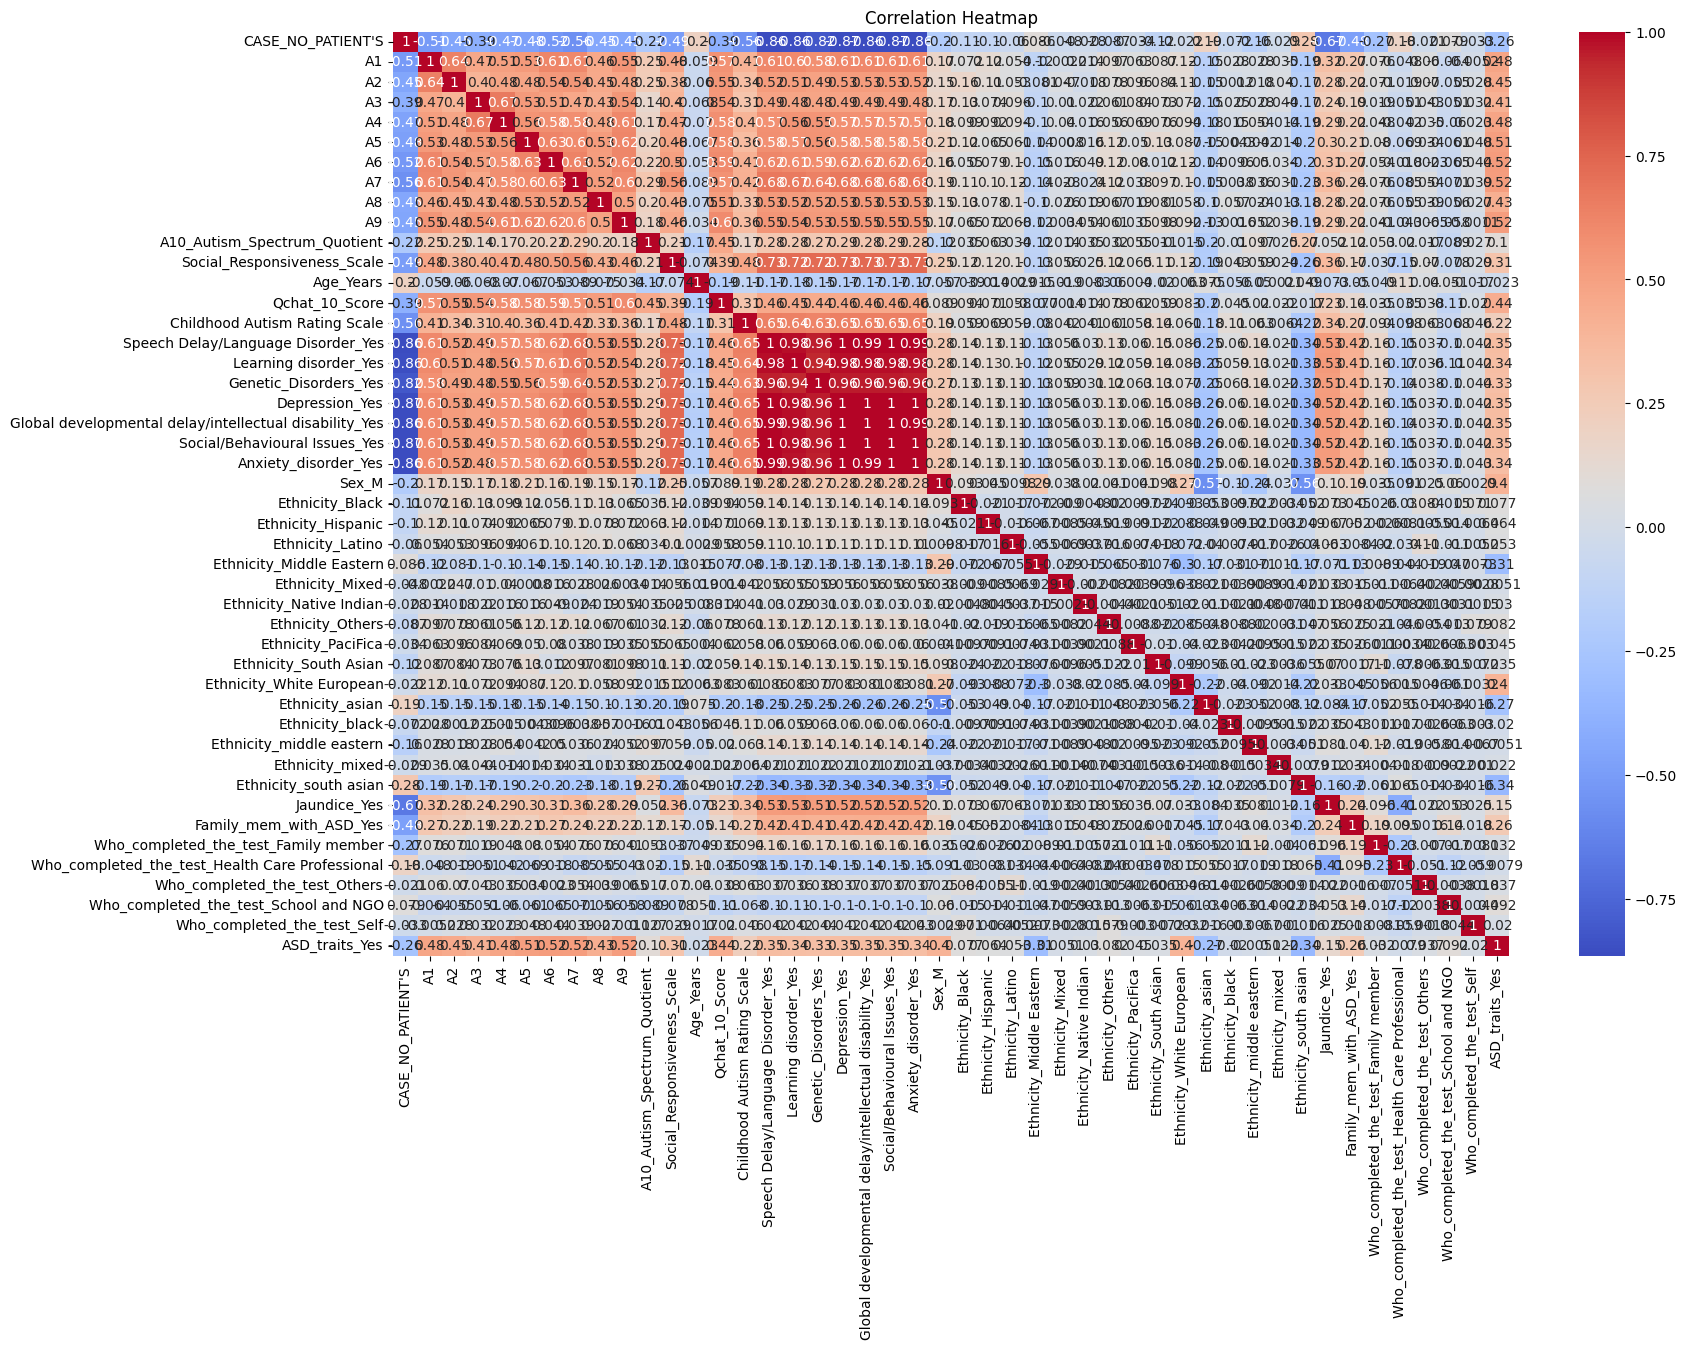

In [13]:
df_encoded = pd.get_dummies(df)

# Plot the correlation heatmap
plt.figure(figsize=(18, 12))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()  # Show the plot


In [14]:
# Step 4: Feature Selection
X = df_cleaned.drop(columns=["asd_traits"], errors='ignore')  # Features
y = df_cleaned["asd_traits"]  # Target

In [15]:
# Hybrid Kernel Function: Combination of RBF, Polynomial, and Linear Kernel
def hybrid_kernel(X, Y, gamma=0.5, coef=1, degree=3, alpha=0.4, beta=0.3):
    K_rbf = rbf_kernel(X, Y, gamma=gamma)
    K_poly = polynomial_kernel(X, Y, degree=degree, coef0=coef)
    K_linear = linear_kernel(X, Y)
    return alpha * K_rbf + beta * K_poly + (1 - alpha - beta) * K_linear

In [16]:
# Import required modules
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Generate sample dataset
X, y = make_classification(n_samples=500, n_features=20, random_state=42)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [17]:
from sklearn.svm import SVC
from sklearn.metrics.pairwise import rbf_kernel, polynomial_kernel, linear_kernel

# Define Hybrid Kernel Function
def hybrid_kernel(X, Y, gamma=0.5, coef=1, degree=3, alpha=0.4, beta=0.3):
    K_rbf = rbf_kernel(X, Y, gamma=gamma)
    K_poly = polynomial_kernel(X, Y, degree=degree, coef0=coef)
    K_linear = linear_kernel(X, Y)
    return alpha * K_rbf + beta * K_poly + (1 - alpha - beta) * K_linear

# Train SVM with Hybrid Kernel
svm_hybrid = SVC(kernel=lambda X, Y: hybrid_kernel(X, Y, gamma=0.1, coef=1, degree=3, alpha=0.4, beta=0.3))
svm_hybrid.fit(X_train, y_train)



SVC(kernel=<function <lambda> at 0x000001F02A9CD1C0>)

In [18]:
# Step 4: Initialize Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
print("Random Forest Model Initialized")

Random Forest Model Initialized


In [19]:
# Step 5: Train the Model
rf_model.fit(X_train, y_train)
print("Model Training Completed")

Model Training Completed


In [20]:
# Step 6: Make Predictions
y_pred = rf_model.predict(X_test)
print("Predictions Generated")

Predictions Generated


In [21]:
# Step 7: Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)


In [22]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")

Mean Squared Error (MSE): 0.05


In [23]:
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:\n", report)


Accuracy: 0.95
Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96        55
           1       1.00      0.89      0.94        45

    accuracy                           0.95       100
   macro avg       0.96      0.94      0.95       100
weighted avg       0.95      0.95      0.95       100



In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import itertools

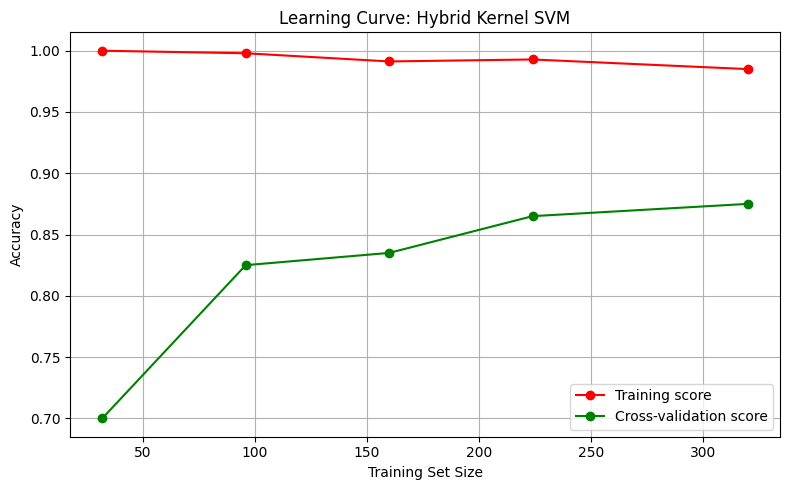

In [25]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.svm import SVC
from sklearn.metrics.pairwise import rbf_kernel, polynomial_kernel, linear_kernel
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# Define the hybrid kernel function
def hybrid_kernel(X, Y, gamma=0.5, coef=1, degree=3, alpha=0.4, beta=0.3):
    K_rbf = rbf_kernel(X, Y, gamma=gamma)
    K_poly = polynomial_kernel(X, Y, degree=degree, coef0=coef)
    K_linear = linear_kernel(X, Y)
    return alpha * K_rbf + beta * K_poly + (1 - alpha - beta) * K_linear

# Custom estimator to wrap hybrid kernel
class HybridSVM(BaseEstimator, ClassifierMixin):
    def __init__(self, gamma=0.5, coef=1, degree=3, alpha=0.4, beta=0.3, C=1.0):
        self.gamma = gamma
        self.coef = coef
        self.degree = degree
        self.alpha = alpha
        self.beta = beta
        self.C = C
        self.model = None

    def fit(self, X, y):
        self.X_train_ = X
        K_train = hybrid_kernel(X, X, self.gamma, self.coef, self.degree, self.alpha, self.beta)
        self.model = SVC(kernel='precomputed', C=self.C)
        self.model.fit(K_train, y)
        return self

    def predict(self, X):
        K_test = hybrid_kernel(X, self.X_train_, self.gamma, self.coef, self.degree, self.alpha, self.beta)
        return self.model.predict(K_test)

# Generate dataset
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=500, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize custom Hybrid SVM
hybrid_svm = HybridSVM(gamma=0.1, coef=1, degree=3, alpha=0.4, beta=0.3, C=1.0)

# Learning curve
train_sizes, train_scores, test_scores = learning_curve(
    hybrid_svm, X_train, y_train, cv=5, scoring='accuracy',
    train_sizes=[0.1, 0.3, 0.5, 0.7, 1.0]
)

# Plot
train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
plt.title("Learning Curve: Hybrid Kernel SVM")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()


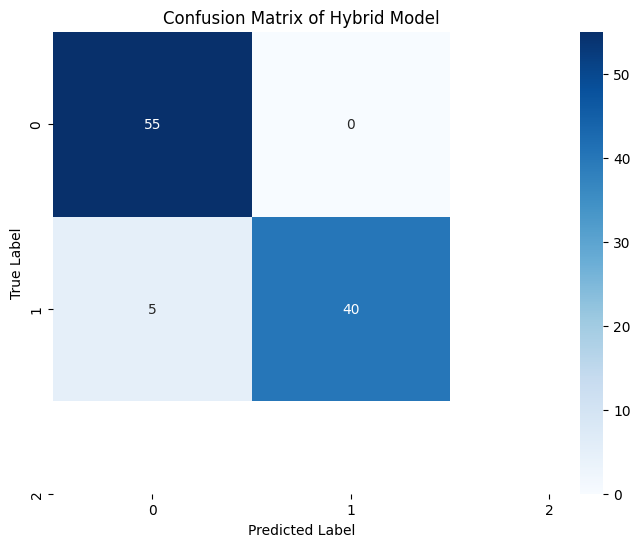

In [26]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])

# Add titles and labels
plt.title('Confusion Matrix of Hybrid Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Display the plot
plt.show()

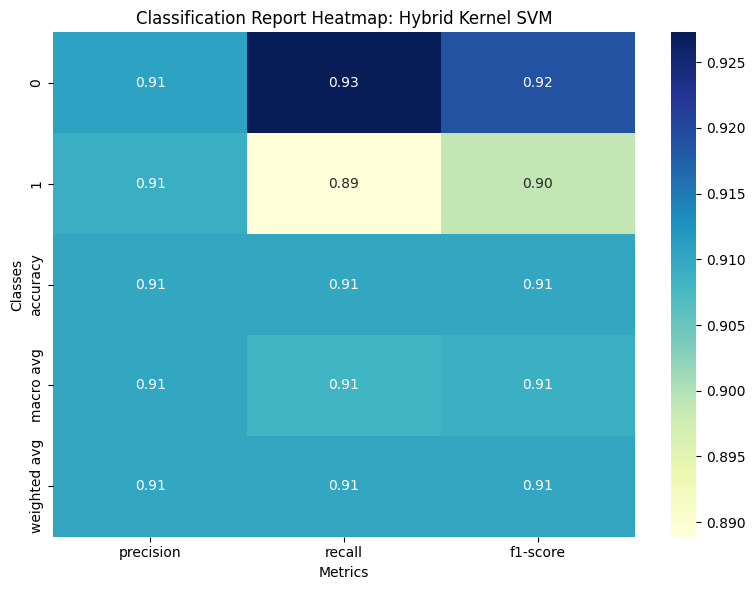

In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Step 1: Predict using the trained hybrid SVM
y_pred_svm = svm_hybrid.predict(X_test)

# Step 2: Generate classification report as a dictionary
report_dict = classification_report(y_test, y_pred_svm, output_dict=True)

# Step 3: Convert to DataFrame
report_df = pd.DataFrame(report_dict).iloc[:-1, :].T  # exclude 'accuracy'

# Step 4: Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(report_df, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report Heatmap: Hybrid Kernel SVM")
plt.xlabel("Metrics")
plt.ylabel("Classes")
plt.tight_layout()
plt.show()

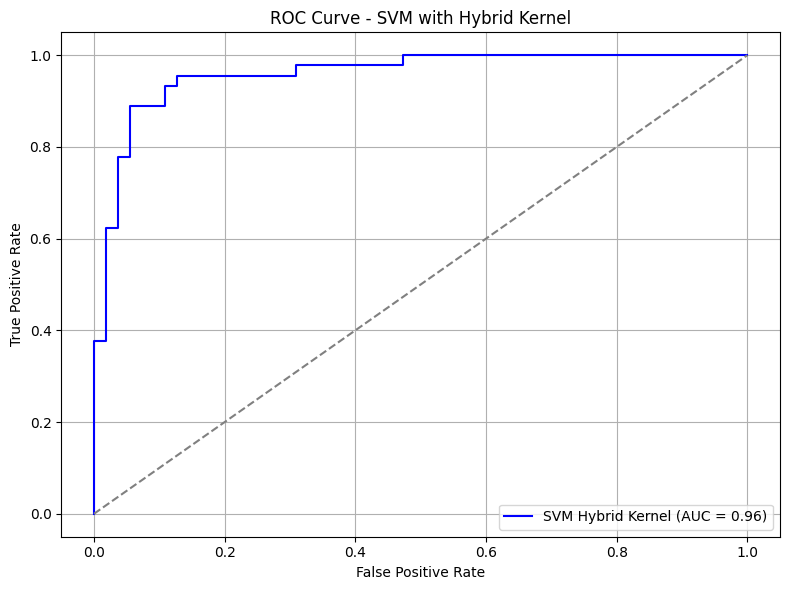

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import pairwise
from sklearn.metrics import roc_curve, auc

# Generate sample dataset
X, y = make_classification(n_samples=500, n_features=20, random_state=42)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define Hybrid Kernel Function
def hybrid_kernel(X, Y, gamma=0.5, coef=1, degree=3, alpha=0.4, beta=0.3):
    K_rbf = pairwise.rbf_kernel(X, Y, gamma=gamma)
    K_poly = pairwise.polynomial_kernel(X, Y, degree=degree, coef0=coef)
    K_linear = pairwise.linear_kernel(X, Y)
    return alpha * K_rbf + beta * K_poly + (1 - alpha - beta) * K_linear

# Train SVM with Hybrid Kernel
svm_hybrid = SVC(kernel=lambda X, Y: hybrid_kernel(X, Y, gamma=0.1, coef=1, degree=3, alpha=0.4, beta=0.3), probability=True)
svm_hybrid.fit(X_train, y_train)

# Get predicted probabilities
svm_probs = svm_hybrid.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_probs)
roc_auc_svm = auc(fpr_svm, tpr_svm)

# Plot ROC Curve for SVM only
plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, color='blue', label=f'SVM Hybrid Kernel (AUC = {roc_auc_svm:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM with Hybrid Kernel')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


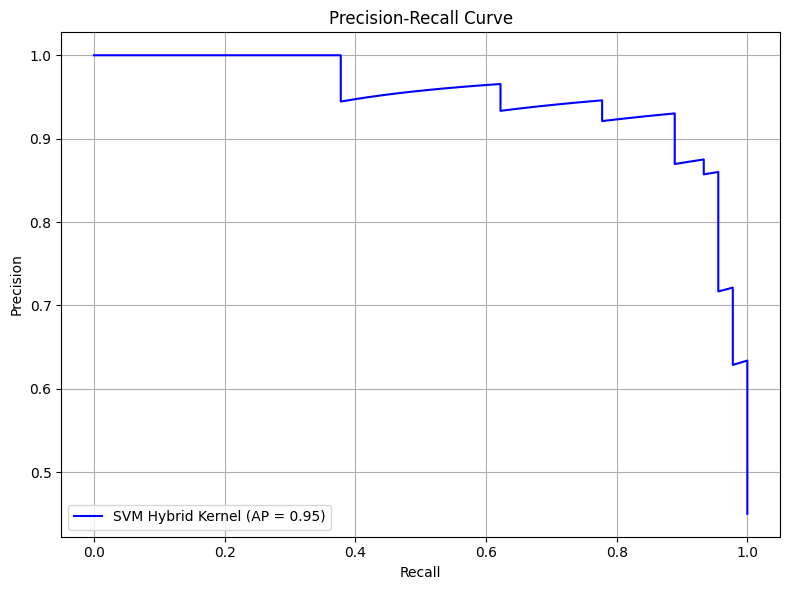

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import pairwise
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score

# Generate sample dataset
X, y = make_classification(n_samples=500, n_features=20, random_state=42)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define Hybrid Kernel Function
def hybrid_kernel(X, Y, gamma=0.5, coef=1, degree=3, alpha=0.4, beta=0.3):
    K_rbf = pairwise.rbf_kernel(X, Y, gamma=gamma)
    K_poly = pairwise.polynomial_kernel(X, Y, degree=degree, coef0=coef)
    K_linear = pairwise.linear_kernel(X, Y)
    return alpha * K_rbf + beta * K_poly + (1 - alpha - beta) * K_linear

# Train SVM with Hybrid Kernel
svm_hybrid = SVC(kernel=lambda X, Y: hybrid_kernel(X, Y, gamma=0.1, coef=1, degree=3, alpha=0.4, beta=0.3), probability=True)
svm_hybrid.fit(X_train, y_train)

# Initialize and Train Random Forest
# rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
# rf_model.fit(X_train, y_train)

# Get predicted probabilities for precision-recall curve
svm_probs = svm_hybrid.predict_proba(X_test)[:, 1]
# rf_probs = rf_model.predict_proba(X_test)[:, 1]

# Calculate Precision-Recall curve for SVM
precision_svm, recall_svm, _ = precision_recall_curve(y_test, svm_probs)
average_precision_svm = average_precision_score(y_test, svm_probs)

# Calculate Precision-Recall curve for Random Forest
# precision_rf, recall_rf, _ = precision_recall_curve(y_test, rf_probs)
# average_precision_rf = average_precision_score(y_test, rf_probs)

# Plot Precision-Recall Curve for both models
plt.figure(figsize=(8, 6))
plt.plot(recall_svm, precision_svm, color='blue', label=f'SVM Hybrid Kernel (AP = {average_precision_svm:.2f})')
# plt.plot(recall_rf, precision_rf, color='green', label=f'Random Forest (AP = {average_precision_rf:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.tight_layout()
plt.show()


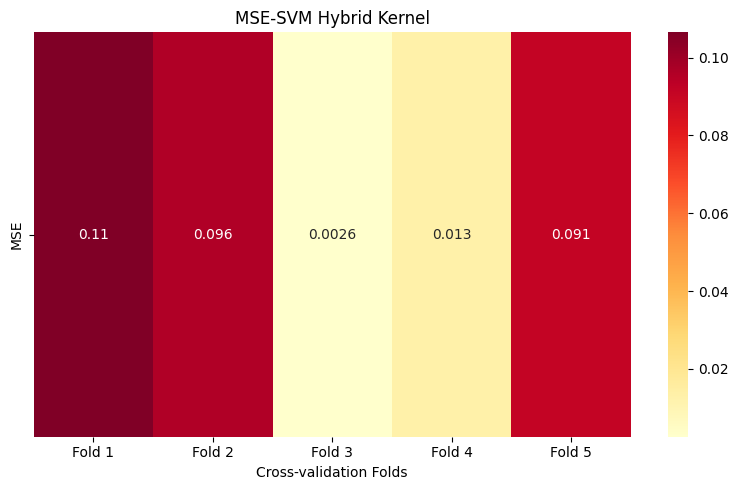

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import rbf_kernel, polynomial_kernel, linear_kernel

# Load dataset (replace this with your actual dataset)
file_path = r"H:\Master Files\cleaned_data.xlsx"
df = pd.read_excel(file_path, engine="openpyxl")

# Drop irrelevant columns and preprocess
df_cleaned = df.drop(columns=["CASE_NO_PATIENT'S"], errors='ignore')

# Encode categorical variables
label_encoders = {}
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    df_cleaned[col] = le.fit_transform(df_cleaned[col])
    label_encoders[col] = le

# Feature selection (assuming 'ASD_traits' is the target)
X = df_cleaned.drop(columns=["ASD_traits"], errors='ignore')  # Features
y = df_cleaned["ASD_traits"]  # Target

# Define Hybrid Kernel Function
def hybrid_kernel(X, Y, gamma=0.5, coef=1, degree=3, alpha=0.4, beta=0.3):
    K_rbf = rbf_kernel(X, Y, gamma=gamma)
    K_poly = polynomial_kernel(X, Y, degree=degree, coef0=coef)
    K_linear = linear_kernel(X, Y)
    return alpha * K_rbf + beta * K_poly + (1 - alpha - beta) * K_linear

# Initialize the SVM classifier with the custom hybrid kernel
svm_model = SVC(kernel=lambda X, Y: hybrid_kernel(X, Y, gamma=0.1, coef=1, degree=3, alpha=0.4, beta=0.3), probability=True)

# Create a custom scoring function for MSE
mse_scorer = make_scorer(mean_squared_error)

# Perform cross-validation to get MSE values
cv_scores = cross_val_score(svm_model, X, y, cv=5, scoring=mse_scorer)

# Visualization of MSE in a Single Rectangle
plt.figure(figsize=(8, 5))
sns.heatmap(cv_scores.reshape(1, -1), annot=True, cmap='YlOrRd', cbar=True, 
            xticklabels=[f'Fold {i+1}' for i in range(len(cv_scores))], 
            yticklabels=["MSE"])
plt.title('MSE-SVM Hybrid Kernel')
plt.xlabel('Cross-validation Folds')
plt.tight_layout()
plt.show()
